In [1]:
# importing the dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
### loading the dataset

df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [7]:
# checking the missing values
df.isnull().sum().sort_values(ascending=False)

Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Date                 0
Location             0
dtype: int64

In [8]:
##  Required Features 
df = df[[
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 
    'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainTomorrow'
]]



In [9]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,13.4,22.9,0.6,NaN,NaN,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No
1,7.4,25.1,0.0,NaN,NaN,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No
2,12.9,25.7,0.0,NaN,NaN,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
3,9.2,28.0,0.0,NaN,NaN,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
4,17.5,32.3,1.0,NaN,NaN,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No


In [10]:
df.shape

(145460, 19)

In [11]:
## Handling missing values

# for Numerical values by using Median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


C:\Users\hp\AppData\Local\Temp\ipykernel_14928\1345004709.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [12]:
# For Categorical
cat_cols = ['WindDir9am', 'WindDir3pm']
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


C:\Users\hp\AppData\Local\Temp\ipykernel_14928\1756433372.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        145460 non-null  float64
 1   MaxTemp        145460 non-null  float64
 2   Rainfall       145460 non-null  float64
 3   Evaporation    145460 non-null  float64
 4   Sunshine       145460 non-null  float64
 5   WindGustSpeed  145460 non-null  float64
 6   WindDir9am     145460 non-null  object 
 7   WindDir3pm     145460 non-null  object 
 8   WindSpeed9am   145460 non-null  float64
 9   WindSpeed3pm   145460 non-null  float64
 10  Humidity9am    145460 non-null  float64
 11  Humidity3pm    145460 non-null  float64
 12  Pressure9am    145460 non-null  float64
 13  Pressure3pm    145460 non-null  float64
 14  Cloud9am       145460 non-null  float64
 15  Cloud3pm       145460 non-null  float64
 16  Temp9am        145460 non-null  float64
 17  Temp3pm        145460 non-nul

In [14]:
df.isnull().sum()

MinTemp             0
MaxTemp             0
Rainfall            0
Evaporation         0
Sunshine            0
WindGustSpeed       0
WindDir9am          0
WindDir3pm          0
WindSpeed9am        0
WindSpeed3pm        0
Humidity9am         0
Humidity3pm         0
Pressure9am         0
Pressure3pm         0
Cloud9am            0
Cloud3pm            0
Temp9am             0
Temp3pm             0
RainTomorrow     3267
dtype: int64

In [15]:
# Converting the Target into YES -1 And No -0
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})


C:\Users\hp\AppData\Local\Temp\ipykernel_14928\50337438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})


In [16]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,13.4,22.9,0.6,4.8,8.4,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0.0
1,7.4,25.1,0.0,4.8,8.4,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0.0
2,12.9,25.7,0.0,4.8,8.4,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0.0
3,9.2,28.0,0.0,4.8,8.4,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0.0
4,17.5,32.3,1.0,4.8,8.4,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0


In [24]:
df['RainTomorrow'].unique()

array([ 0.,  1., nan])

In [25]:
## Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['WindDir9am'] = le.fit_transform(df['WindDir9am'])
df['WindDir3pm'] = le.fit_transform(df['WindDir3pm'])


C:\Users\hp\AppData\Local\Temp\ipykernel_14928\1067253130.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WindDir9am'] = le.fit_transform(df['WindDir9am'])
C:\Users\hp\AppData\Local\Temp\ipykernel_14928\1067253130.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WindDir3pm'] = le.fit_transform(df['WindDir3pm'])


In [26]:
plt.style.use("ggplot")

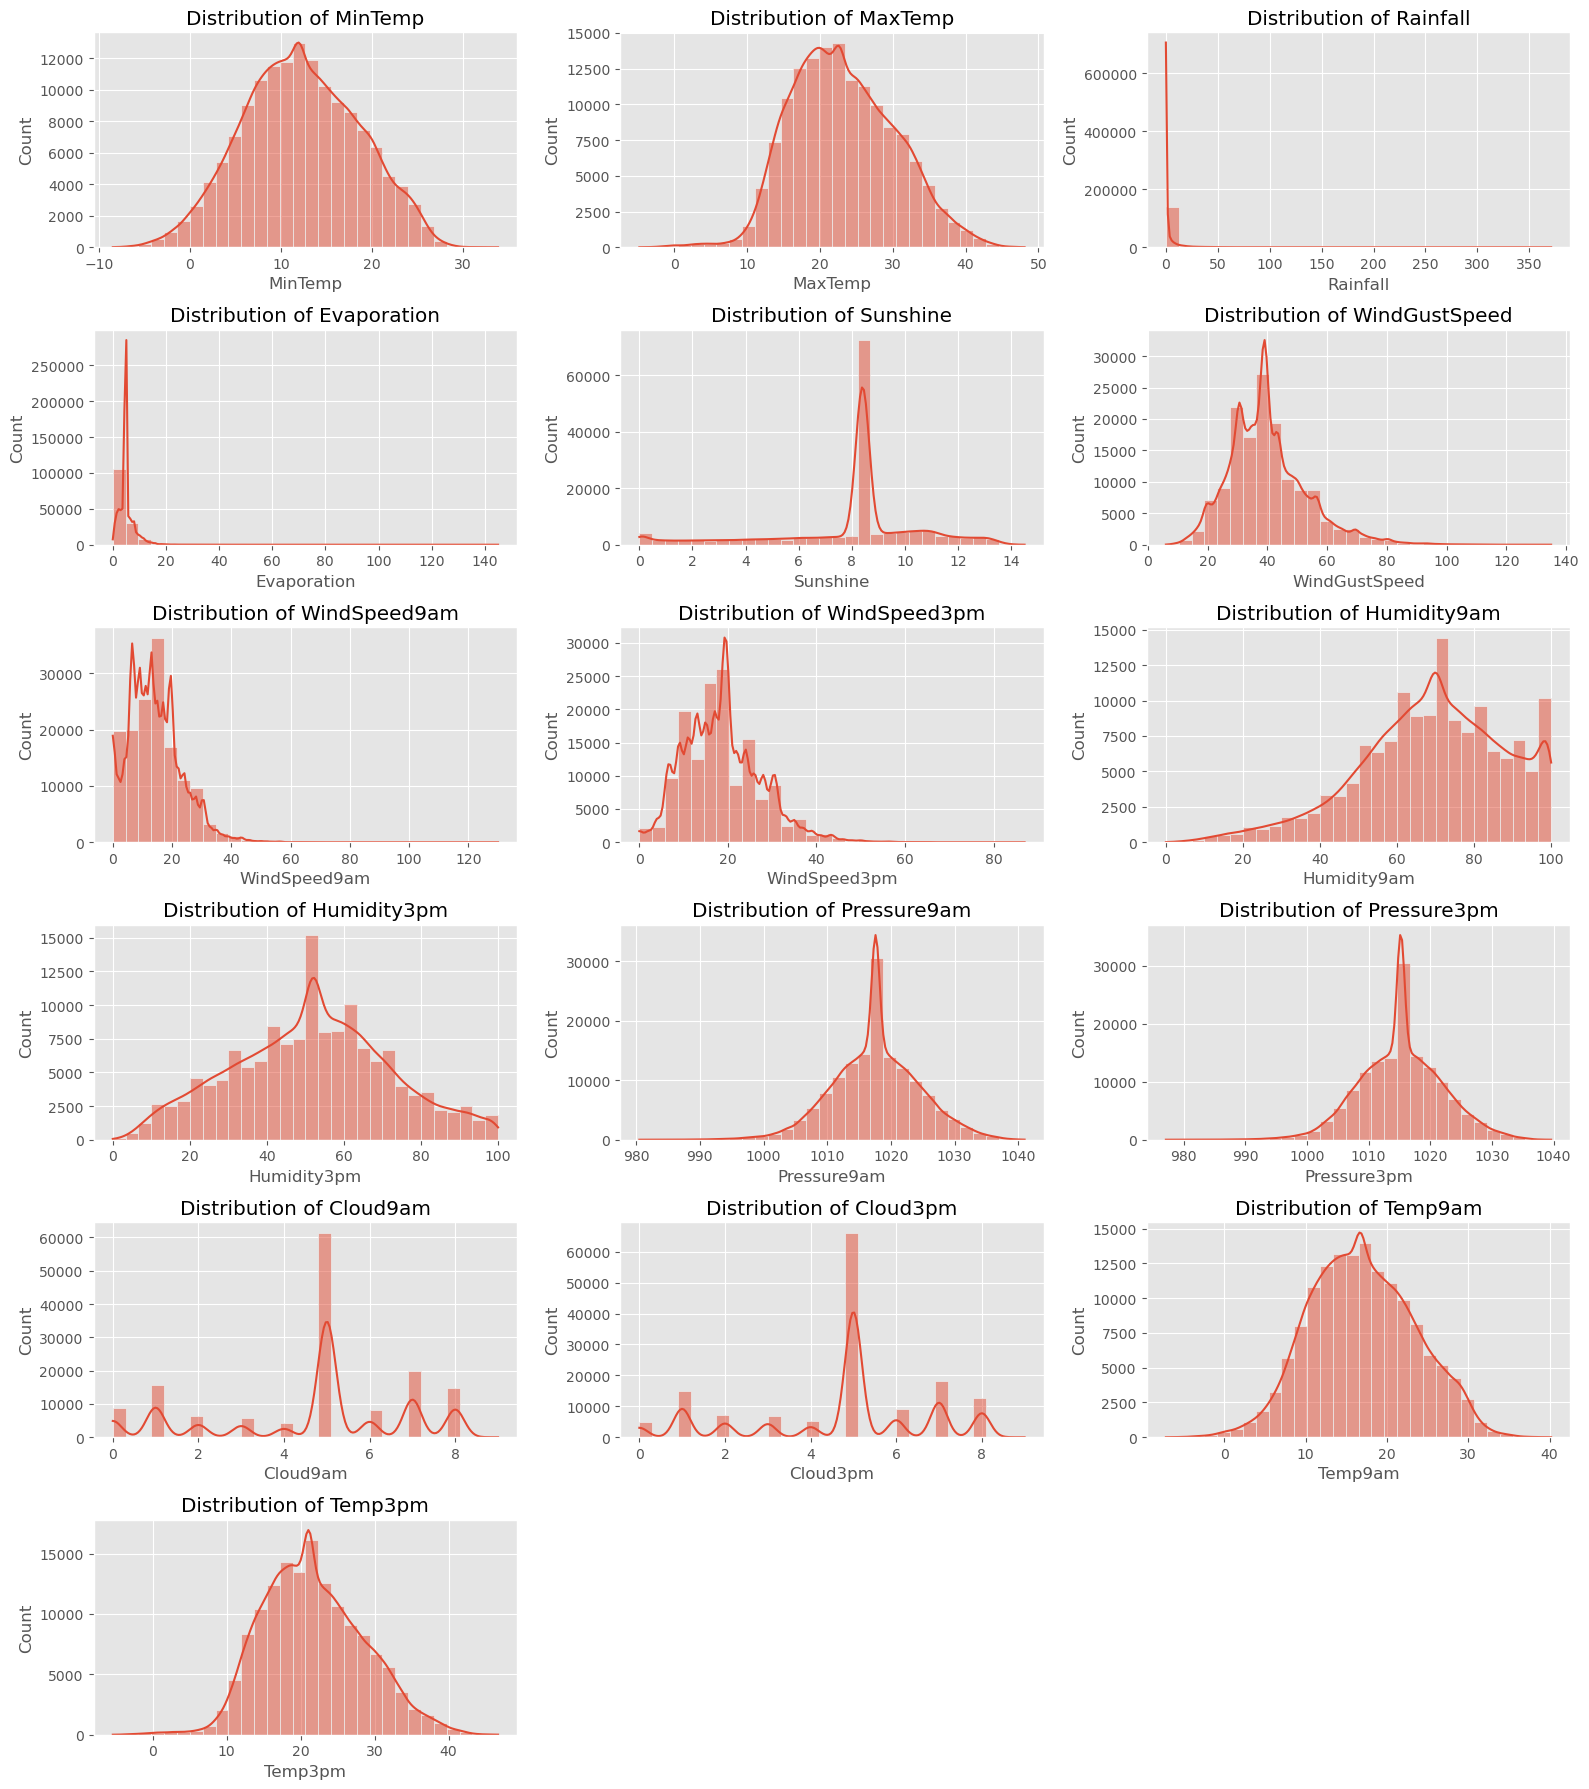

In [27]:
num_features = ['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine',
                'WindGustSpeed','WindSpeed9am','WindSpeed3pm',
                'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
                'Cloud9am','Cloud3pm','Temp9am','Temp3pm']

plt.figure(figsize=(16, 18))

for i, col in enumerate(num_features, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


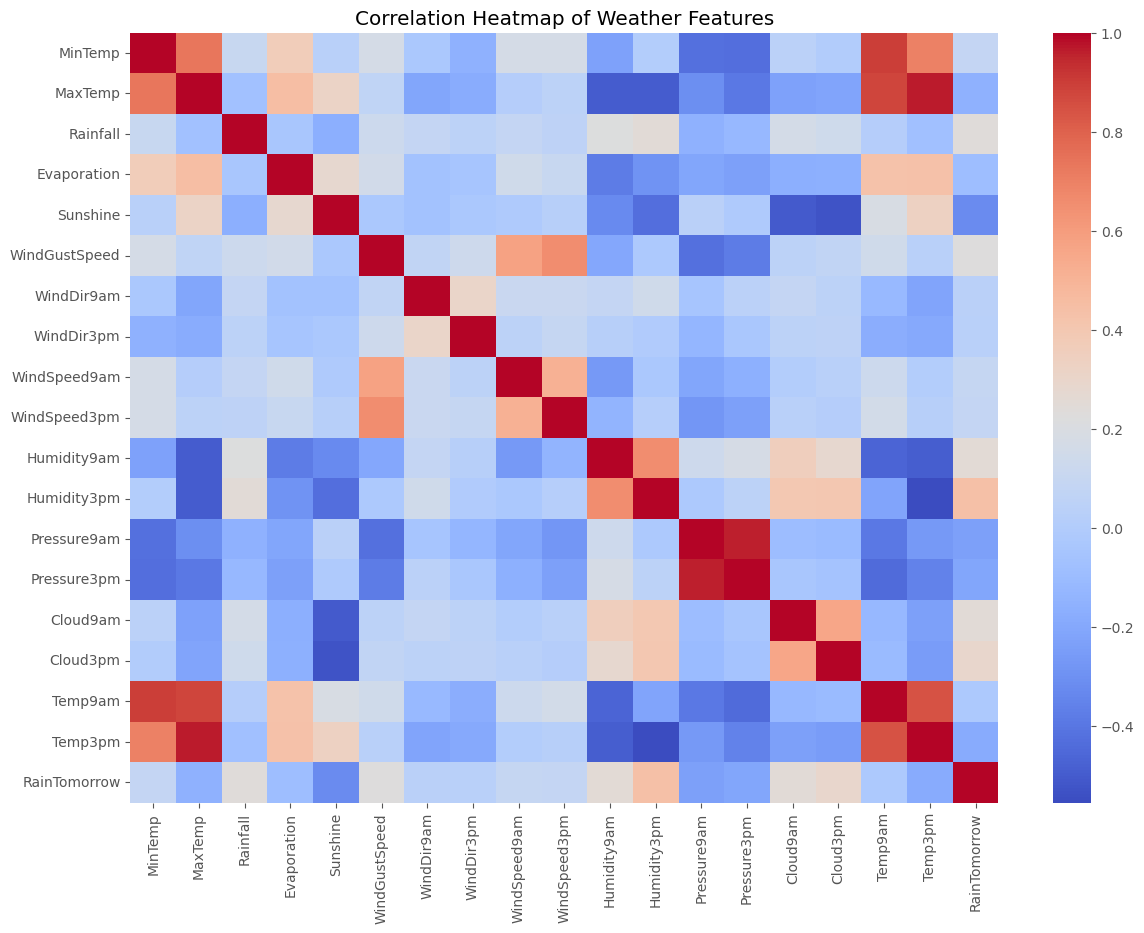

In [28]:
## Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Weather Features")
plt.show()


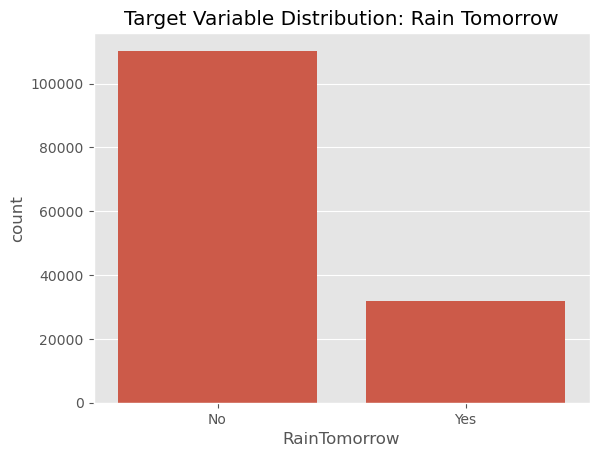

In [29]:
sns.countplot(x=df['RainTomorrow'])
plt.title("Target Variable Distribution: Rain Tomorrow")
plt.xticks([0,1], ["No", "Yes"])
plt.show()


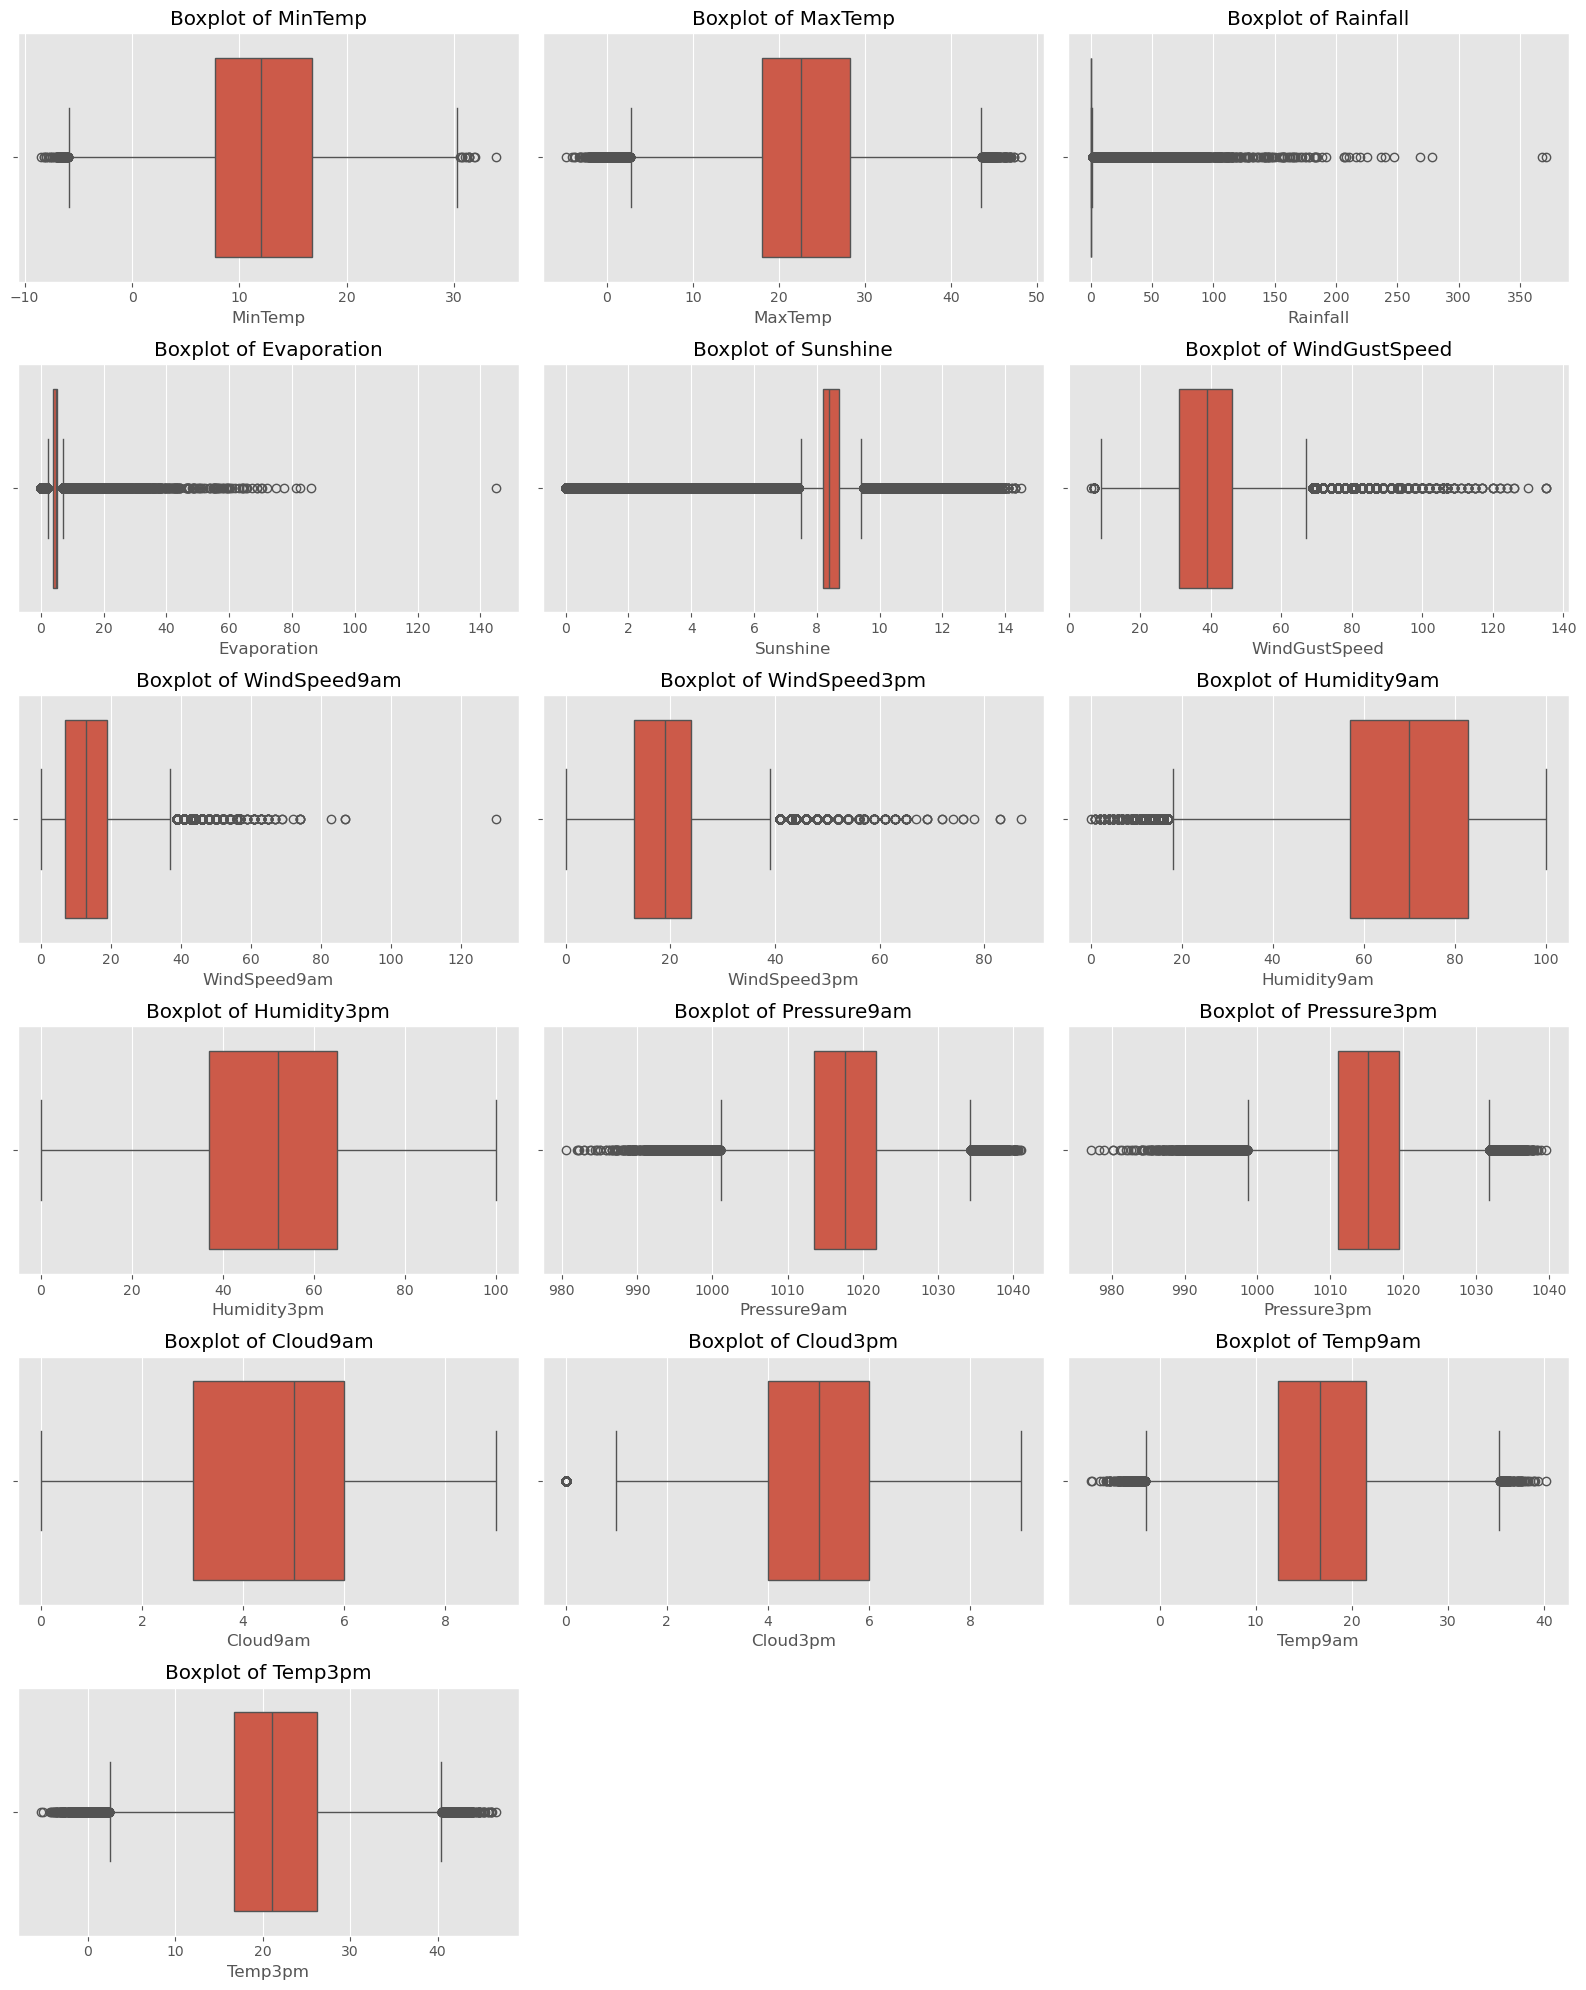

In [30]:
# Boxplots for Outlier Detection

plt.figure(figsize=(16, 20))

for i, col in enumerate(num_features, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


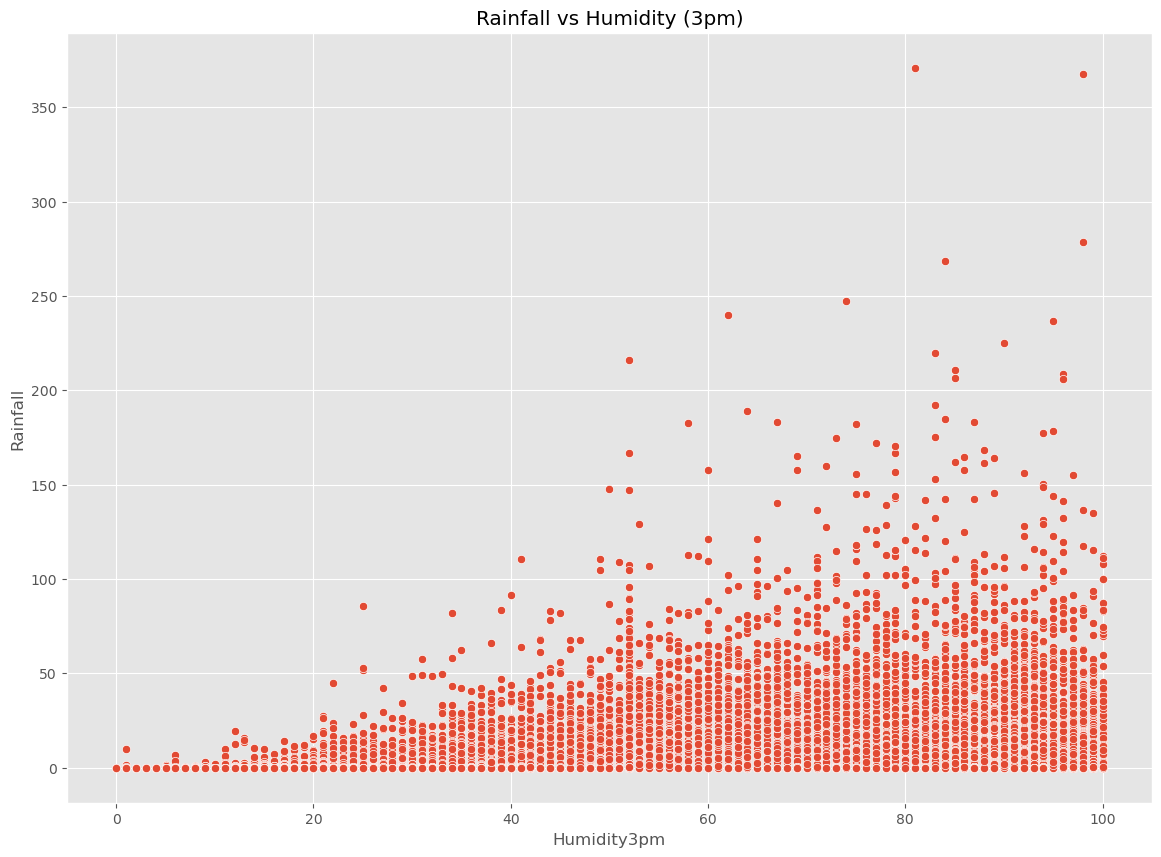

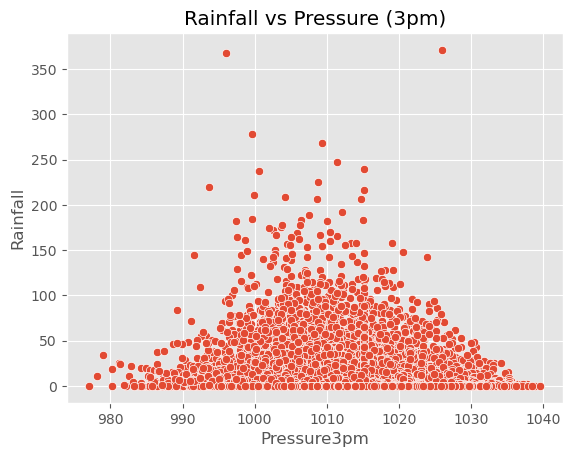

In [31]:
plt.figure(figsize=(14,10))

sns.scatterplot(x=df['Humidity3pm'], y=df['Rainfall'])
plt.title("Rainfall vs Humidity (3pm)")
plt.show()

sns.scatterplot(x=df['Pressure3pm'], y=df['Rainfall'])
plt.title("Rainfall vs Pressure (3pm)")
plt.show()


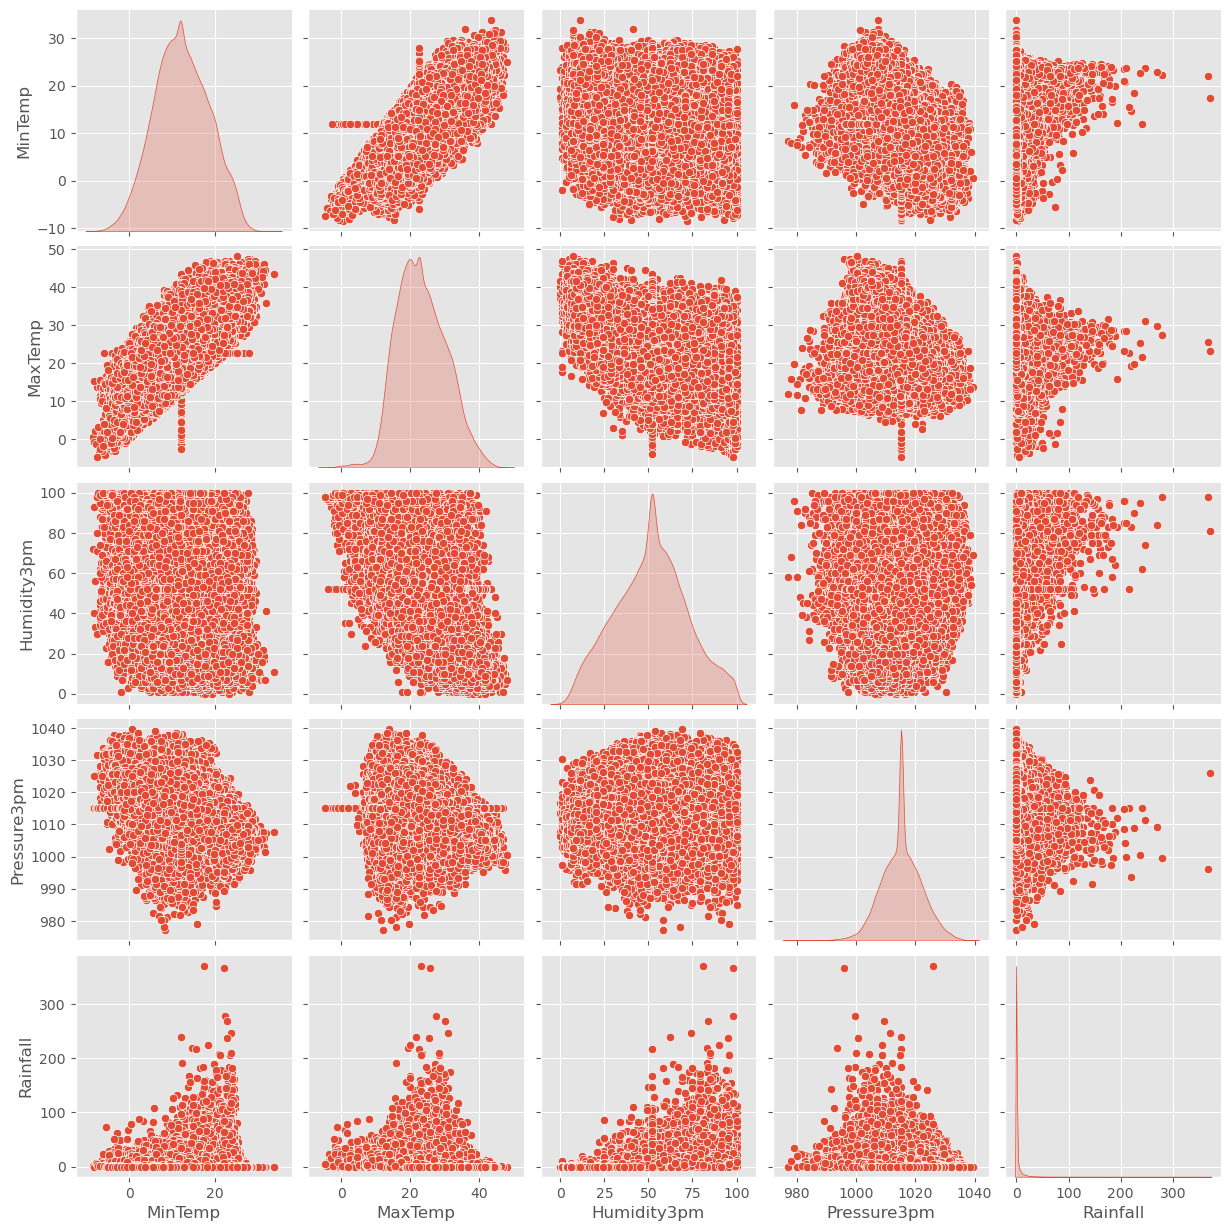

In [32]:
sns.pairplot(df[['MinTemp','MaxTemp','Humidity3pm','Pressure3pm','Rainfall']], diag_kind='kde')
plt.show()


In [33]:
# importing required dependencies
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


In [34]:
# spliting the data into features and targets
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]


In [42]:
y = y.fillna(y.mode()[0])   # for NAN value convert into mode

In [44]:
y.unique()

array([0., 1.])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [46]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [47]:
## Prediction and evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8581053210504606

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     22717
         1.0       0.77      0.50      0.61      6375

    accuracy                           0.86     29092
   macro avg       0.82      0.73      0.76     29092
weighted avg       0.85      0.86      0.85     29092


Confusion Matrix:
 [[21781   936]
 [ 3192  3183]]


In [48]:
# Save the Model for Deployment
joblib.dump(model, "rain_prediction_model.pkl")


['rain_prediction_model.pkl']

# Save Feature Columns (IMPORTANT)

We store the column order so Streamlit can use exactly the same structure:

In [49]:
joblib.dump(list(X.columns), "model_features.pkl")


['model_features.pkl']

In [50]:
df_raw = pd.read_csv("weatherAUS.csv")
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [51]:
# Select a single weather station (important)

# Weather varies by city.
# So we must filter one location.


city = "Sydney"
df_city = df_raw[df_raw["Location"] == city]
df_city = df_city[["Date", "Rainfall"]].dropna()
df_city = df_city.sort_values("Date")
df_city.head()


,Date,Rainfall
30176,2008-02-01,15.6
30177,2008-02-02,6.0
30178,2008-02-03,6.6
30179,2008-02-04,18.8
30180,2008-02-05,77.4


In [52]:
## PRepare Dataset for prophet
df_prophet = df_city.rename(columns={"Date": "ds", "Rainfall": "y"})
df_prophet.head()


,ds,y
30176,2008-02-01,15.6
30177,2008-02-02,6.0
30178,2008-02-03,6.6
30179,2008-02-04,18.8
30180,2008-02-05,77.4


# PART A — FORECASTING WITH PROPHET

In [53]:
!pip install PROPHET

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.0 MB/s eta 0:00:12
   --- ------------------------------------ 1.0/12.1 MB 1.7 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/12.1 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.1 MB 2.1 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.1 MB 2.4 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 2.6 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 5.0/12.1 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 2.4 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 2.5 MB/s eta 0:00:03
   ----------

In [54]:
# train prophet model
from prophet import Prophet

model_prophet = Prophet()
model_prophet.fit(df_prophet)


23:11:03 - cmdstanpy - INFO - Chain [1] start processing
23:11:04 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
## Creating futures Dates
future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)


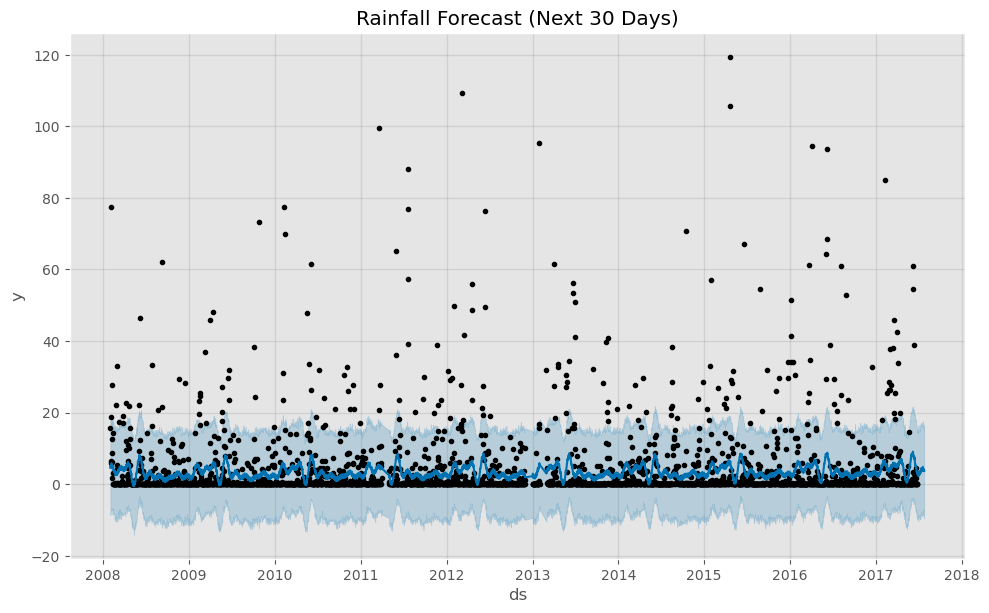

In [56]:
# plot forecast
model_prophet.plot(forecast)
plt.title("Rainfall Forecast (Next 30 Days)")
plt.show()


In [57]:
# save forecasting model
import joblib
joblib.dump(model_prophet, "rainfall_prophet_model.pkl")


['rainfall_prophet_model.pkl']

PART B — LSTM TIME SERIES FORECASTING

LSTM requires:

✔ Normalized data
✔ Windowed sequences
✔ Train/Validation split

In [58]:
# prepare date for LSTM
from sklearn.preprocessing import MinMaxScaler

df_lstm = df_city.copy()
df_lstm = df_lstm[["Date", "Rainfall"]]

scaler = MinMaxScaler()
df_lstm["Scaled"] = scaler.fit_transform(df_lstm[["Rainfall"]])


In [59]:
# Create sequence windows

# The model learns from past 30 days to predict the next day.

import numpy as np

def create_sequences(data, seq=30):
    X, y = [], []
    for i in range(len(data)-seq):
        X.append(data[i:i+seq])
        y.append(data[i+seq])
    return np.array(X), np.array(y)

values = df_lstm["Scaled"].values
X, y = create_sequences(values, 30)


In [60]:
# train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [62]:
# Build LSTM MOdel

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(30,1)),
    LSTM(32, activation='tanh'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0058 - val_loss: 0.0072
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0057 - val_loss: 0.0071
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0057 - val_loss: 0.0070
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0057 - val_loss: 0.0068
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0055 - val_loss: 0.0067
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0055 - val_loss: 0.0066
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0054 - val_loss: 0.0063
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0054 - val_loss: 0.0063
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0054 - val_loss: 0.0062
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0054 - val_loss: 0.0062
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0054 - val_loss: 0.0063
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0

In [63]:
# save LSTM 
model_lstm.save("rainfall_lstm_model.h5")
joblib.dump(scaler, "lstm_scaler.pkl")


['lstm_scaler.pkl']